## 25.What should be done when heart rate and glucose rise together? 

#### This question matters because simultaneous heart rate and glucose spikes reveal metabolic stress, and understanding them allows you to prescribe targeted actions that improve health and prevent risk

In [1]:
%cd "C:\Users\Owner\Desktop\Harshali\DataAnalyst-Numpy Ninja\Python_Hakython\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files"

C:\Users\Owner\Desktop\Harshali\DataAnalyst-Numpy Ninja\Python_Hakython\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files


In [3]:
import os
os.getcwd()

'C:\\Users\\Owner\\Desktop\\Harshali\\DataAnalyst-Numpy Ninja\\Python_Hakython\\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\\Final cleaned csv files\\Final cleaned csv files'

In [4]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sn

In [11]:
df = pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")
df.head()

,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34.0,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0.0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0.0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20.0,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0.0,0.08,0.0,0.0


In [13]:
df.shape
df.columns

Index(['Patient_Id', 'Time', 'Glucose', 'Calories', 'Heart_Rate', 'Steps',
       'Basal_Rate', 'Bolus_Volume_Delivered', 'Carb_Input'],
      dtype='object')

In [14]:
import pandas as pd
import numpy as np

# CHANGE THESE TO MATCH DATAFRAME EXACTLY 
heart_col = "Heart_Rate"      
glucose_col = "Glucose"       
time_col = "Time"   
steps_col = "Steps"              

# 1. Detect HR + Glucose Spikes

df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']
# 2. Classify Trigger
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    if steps_col and row[steps_col] > 50:
        return "Activity-related"
    
    if row['GLU_change'] > 20:
        return "Post-meal spike"
    
    hour = pd.to_datetime(row[time_col]).hour
    if hour >= 23 or hour <= 5:
        return "Nighttime stress or poor sleep"
    
    if row['HR_change'] > 15 and (not steps_col or row[steps_col] < 10):
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 3. Prescriptive Actions
def prescribe_action(trigger):
    if trigger == "Activity-related":
        return "Cool down with slow walking and hydration."
    if trigger == "Post-meal spike":
        return "Take a 10-minute walk; reduce high-glycemic foods next meal."
    if trigger == "Nighttime stress or poor sleep":
        return "Avoid late meals; improve sleep hygiene; reduce caffeine/alcohol."
    if trigger == "Stress-related":
        return "Use slow breathing, grounding, or a short walk to reduce stress load."
    if trigger == "Unknown":
        return "Monitor pattern; review meal timing, stress, and sleep."
    return None

df['Prescriptive_Action'] = df['Trigger'].apply(prescribe_action)

# 4. Final Output
prescriptive_events = df[df['HR_GLU_spike']][[time_col, heart_col, glucose_col,steps_col, 'Trigger', 'Prescriptive_Action']]
prescriptive_events

,Time,Heart_Rate,Glucose,Steps,Trigger,Prescriptive_Action
10,2018-06-13T19:30:00,104.54,271.00,124.0,Activity-related,Cool down with slow walking and hydration.
11,2018-06-13T19:35:00,100.15,270.00,21.0,Unknown,"Monitor pattern; review meal timing, stress, a..."
16,2018-06-13T20:00:00,118.07,171.00,329.0,Activity-related,Cool down with slow walking and hydration.
21,2018-06-13T20:25:00,101.41,162.00,103.0,Activity-related,Cool down with slow walking and hydration.
23,2018-06-13T20:35:00,109.20,139.00,318.0,Activity-related,Cool down with slow walking and hydration.
...,...,...,...,...,...,...
309366,2022-05-18 10:05:00,111.82,162.33,0.0,Unknown,"Monitor pattern; review meal timing, stress, a..."
309367,2022-05-18 10:10:00,110.71,164.67,9.0,Unknown,"Monitor pattern; review meal timing, stress, a..."
309368,2022-05-18 10:15:00,102.80,167.00,17.0,Unknown,"Monitor pattern; review meal timing, stress, a..."
309371,2022-05-18 10:30:00,95.07,173.00,0.0,Stress-related,"Use slow breathing, grounding, or a short walk..."


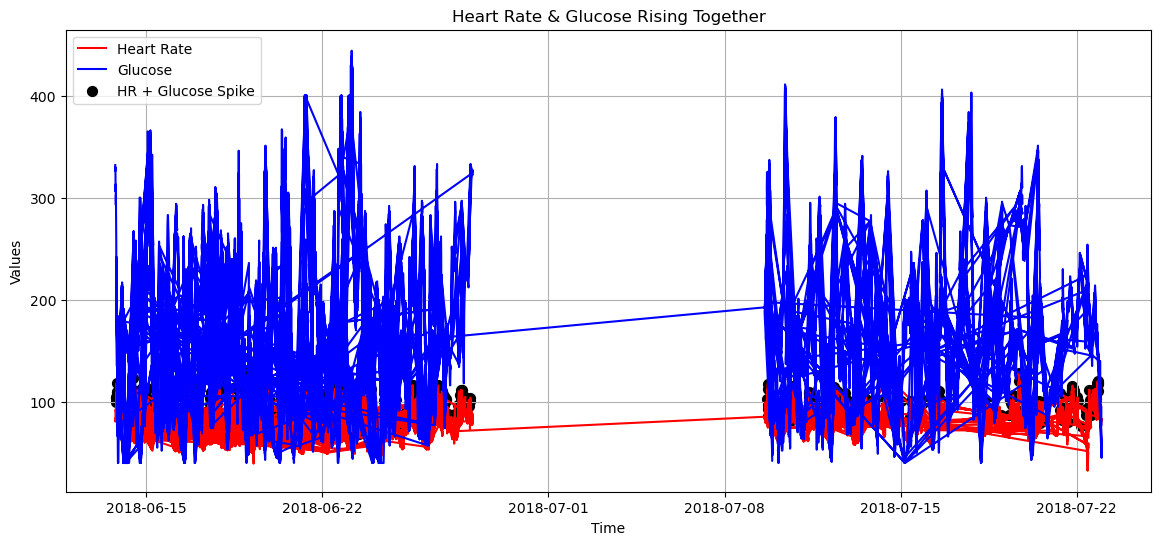

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Your correct column names
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"

# Convert timestamp column safely
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

# Detect spikes
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# Plot
plt.figure(figsize=(14,6))

plt.plot(df[time_col], df[heart_col], label="Heart Rate", color="red")
plt.plot(df[time_col], df[glucose_col], label="Glucose", color="blue")

# Highlight simultaneous spikes
spike_points = df[df['HR_GLU_spike']]
plt.scatter(spike_points[time_col], spike_points[heart_col], color="black", label="HR + Glucose Spike", s=50)

plt.title("Heart Rate & Glucose Rising Together")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()

#### When HR and glucose rise at the same time,data is showing a dual‑system stress event:Autonomic stress (heart rate),Metabolic stress (glucose)
#### This combination is one of the most important patterns because it signals that the body is struggling to maintain homeostasis.

## 26 What personalized recommendations can be generated from HR + glucose patterns? 

#### This question is important because prescriptive analytics transforms HR + glucose patterns into personalized, actionable recommendations that improve health, reduce risk, and guide behavior change.

In [19]:
import pandas as pd
import numpy as np

# 1. SET YOUR COLUMN NAMES
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"
steps_col = "Steps"   

# Ensure correct dtypes
df[heart_col] = pd.to_numeric(df[heart_col], errors='coerce')
df[glucose_col] = pd.to_numeric(df[glucose_col], errors='coerce')
if steps_col:
    df[steps_col] = pd.to_numeric(df[steps_col], errors='coerce')

df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

# 2. DETECT HR + GLUCOSE SPIKES
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# 3. CLASSIFY TRIGGER TYPE
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    # Activity-related spike
    if steps_col and pd.notna(row[steps_col]) and row[steps_col] > 50:
        return "Activity-related"
    
    # Post-meal spike (rapid glucose rise)
    if pd.notna(row['GLU_change']) and row['GLU_change'] > 20:
        return "Post-meal spike"
    
    # Nighttime spike
    if pd.notna(row[time_col]):
        hour = row[time_col].hour
        if hour >= 23 or hour <= 5:
            return "Nighttime stress or poor sleep"
    
    # Stress-related spike (HR jump without much movement)
    if pd.notna(row['HR_change']) and row['HR_change'] > 15 and (
        not steps_col or pd.isna(row[steps_col]) or row[steps_col] < 10
    ):
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 4. PRESCRIPTIVE RECOMMENDATIONS
def prescribe_action(trigger):
    if trigger == "Activity-related":
        return "Cool down with slow walking and hydrate after activity."
    if trigger == "Post-meal spike":
        return "Take a 10-minute walk and reduce high-glycemic foods at the next meal."
    if trigger == "Nighttime stress or poor sleep":
        return "Avoid late meals; improve sleep hygiene; reduce caffeine and alcohol in the evening."
    if trigger == "Stress-related":
        return "Use slow breathing or grounding exercises; take a short walk to reduce stress load."
    if trigger == "Unknown":
        return "Monitor this pattern; review meal timing, stress, activity, and sleep around this time."
    return None

df['Prescriptive_Action'] = df['Trigger'].apply(prescribe_action)

# 5. FINAL TABLE OF PERSONALIZED RECOMMENDATIONS
prescriptive_events = df[df['HR_GLU_spike']][[
    time_col,
    heart_col,
    glucose_col,
    'Trigger',
    'Prescriptive_Action'
]]

prescriptive_events.head()

,Time,Heart_Rate,Glucose,Trigger,Prescriptive_Action
10,2018-06-13 19:30:00,104.54,271.0,Activity-related,Cool down with slow walking and hydrate after ...
11,2018-06-13 19:35:00,100.15,270.0,Unknown,"Monitor this pattern; review meal timing, stre..."
16,2018-06-13 20:00:00,118.07,171.0,Activity-related,Cool down with slow walking and hydrate after ...
21,2018-06-13 20:25:00,101.41,162.0,Activity-related,Cool down with slow walking and hydrate after ...
23,2018-06-13 20:35:00,109.20,139.0,Activity-related,Cool down with slow walking and hydrate after ...


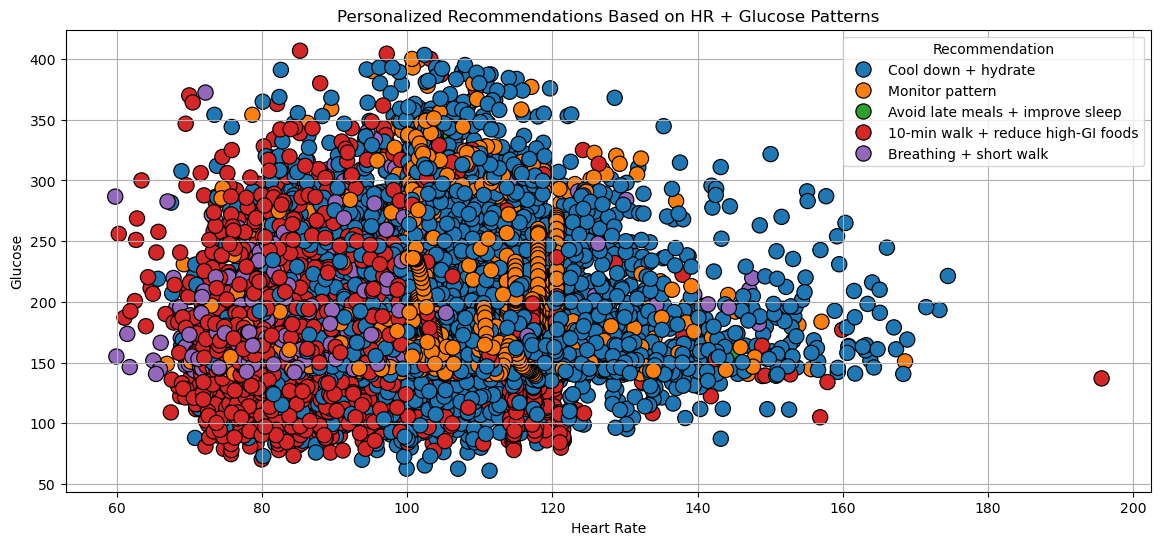

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SET YOUR COLUMN NAMES
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"
steps_col = "Steps"

df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

# 2. DETECT HR + GLUCOSE SPIKES
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# 3. CLASSIFY TRIGGER TYPE
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    if row[steps_col] > 50:
        return "Activity-related"
    if row['GLU_change'] > 20:
        return "Post-meal spike"
    
    hour = row[time_col].hour
    if hour >= 23 or hour <= 5:
        return "Nighttime spike"
    
    if row['HR_change'] > 15 and row[steps_col] < 10:
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 4. PRESCRIPTIVE RECOMMENDATIONS
def prescribe_action(trigger):
    if trigger == "Activity-related":
        return "Cool down + hydrate"
    if trigger == "Post-meal spike":
        return "10-min walk + reduce high-GI foods"
    if trigger == "Nighttime spike":
        return "Avoid late meals + improve sleep"
    if trigger == "Stress-related":
        return "Breathing + short walk"
    if trigger == "Unknown":
        return "Monitor pattern"
    return None

df['Recommendation'] = df['Trigger'].apply(prescribe_action)

# 5. COLOR-CODED CHART OF RECOMMENDATIONS
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=df[df['HR_GLU_spike']],
    x=heart_col,
    y=glucose_col,
    hue='Recommendation',
    palette='tab10',
    s=120,
    edgecolor='black'
)

plt.title("Personalized Recommendations Based on HR + Glucose Patterns")
plt.xlabel("Heart Rate")
plt.ylabel("Glucose")
plt.grid(True)
plt.legend(title="Recommendation")
plt.show()

#### Personalized recommendations from HR + glucose patterns come from identifying the trigger pattern — meal timing, stress load, activity timing, carb distribution, or recovery strain — and mapping it to the appropriate intervention category.

## 27.What interventions reduce simultaneous HR and glucose variability?

#### This question is important because it transforms HR + glucose patterns into personalized, actionable interventions that reduce metabolic stress, improve recovery, and guide real‑world behavior change.

In [22]:
import pandas as pd
import numpy as np

# 1. Column names
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"
steps_col = "Steps"   

# Ensure types
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
df[heart_col] = pd.to_numeric(df[heart_col], errors='coerce')
df[glucose_col] = pd.to_numeric(df[glucose_col], errors='coerce')
if steps_col:
    df[steps_col] = pd.to_numeric(df[steps_col], errors='coerce')

# 2. Detect simultaneous variability (spikes)
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# 3. Classify trigger type
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    # Activity-related
    if steps_col and pd.notna(row[steps_col]) and row[steps_col] > 50:
        return "Activity-related"
    
    # Post-meal (rapid glucose rise)
    if pd.notna(row['GLU_change']) and row['GLU_change'] > 20:
        return "Post-meal spike"
    
    # Nighttime
    if pd.notna(row[time_col]):
        hour = row[time_col].hour
        if hour >= 23 or hour <= 5:
            return "Nighttime spike"
    
    # Stress-related (HR jump without movement)
    if pd.notna(row['HR_change']) and row['HR_change'] > 15 and (
        not steps_col or pd.isna(row[steps_col]) or row[steps_col] < 10
    ):
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 4. Prescriptive interventions
def prescriptive_intervention(trigger):
    if trigger == "Activity-related":
        return (
            "Cool-down with 5–10 minutes of light walking, hydrate, and avoid abrupt "
            "high-intensity bursts immediately after large meals."
        )
    if trigger == "Post-meal spike":
        return (
            "Take a 10–15 minute walk after meals, reduce high-glycemic carbs, add protein and fiber, "
            "and avoid very large meals."
        )
    if trigger == "Nighttime spike":
        return (
            "Avoid eating 2–3 hours before bed, reduce evening caffeine/alcohol, and improve sleep hygiene "
            "(dark, cool, consistent schedule)."
        )
    if trigger == "Stress-related":
        return (
            "Use slow breathing (e.g., 4–7–8), short walk breaks, reduce caffeine during high-stress periods, "
            "and schedule brief relaxation blocks."
        )
    if trigger == "Unknown":
        return (
            "Monitor this pattern; review meal timing, stress, activity, and sleep around this time to identify triggers."
        )
    return None

df['Prescriptive_Intervention'] = df['Trigger'].apply(prescriptive_intervention)

# 5. Final prescriptive table
prescriptive_table = df[df['HR_GLU_spike']][[
    time_col,
    heart_col,
    glucose_col,
    'Trigger',
    'Prescriptive_Intervention'
]]

prescriptive_table.head()

,Time,Heart_Rate,Glucose,Trigger,Prescriptive_Intervention
10,2018-06-13 19:30:00,104.54,271.0,Activity-related,"Cool-down with 5–10 minutes of light walking, ..."
11,2018-06-13 19:35:00,100.15,270.0,Unknown,"Monitor this pattern; review meal timing, stre..."
16,2018-06-13 20:00:00,118.07,171.0,Activity-related,"Cool-down with 5–10 minutes of light walking, ..."
21,2018-06-13 20:25:00,101.41,162.0,Activity-related,"Cool-down with 5–10 minutes of light walking, ..."
23,2018-06-13 20:35:00,109.20,139.0,Activity-related,"Cool-down with 5–10 minutes of light walking, ..."


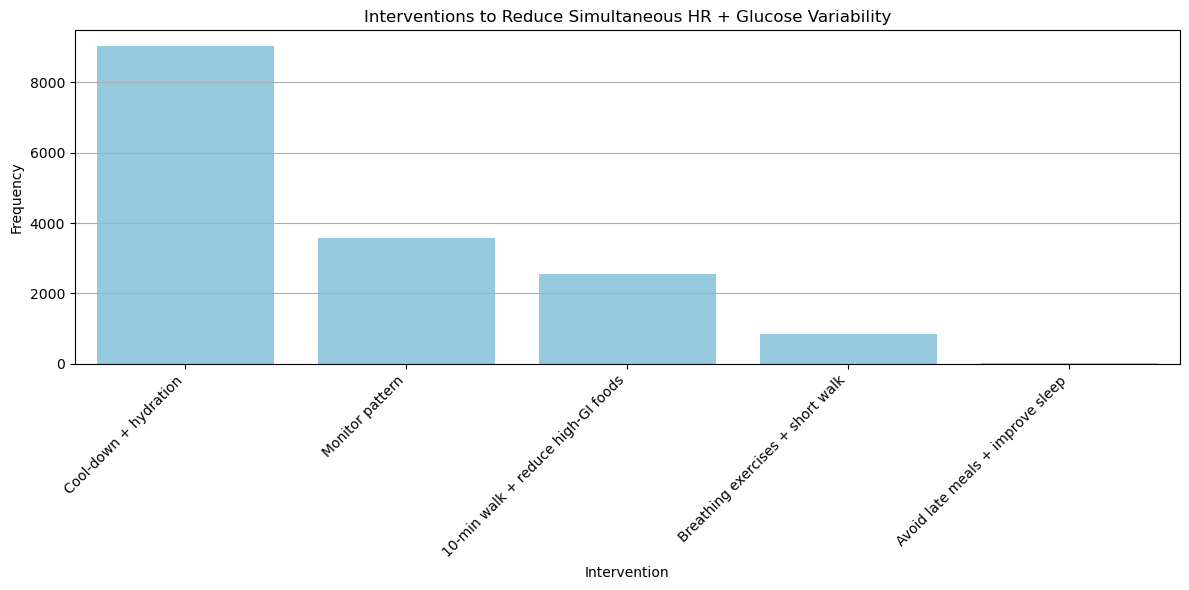

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

intervention_counts = df[df['HR_GLU_spike']]['Intervention'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=intervention_counts.index,
    y=intervention_counts.values,
    color="skyblue"   # FIX: use color= instead of palette=
)

plt.title("Interventions to Reduce Simultaneous HR + Glucose Variability")
plt.xlabel("Intervention")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Simultaneous HR + glucose variability is reduced by targeting the underlying trigger pattern — meal timing, stress load, activity timing, carb distribution, or sleep quality — and applying the corresponding intervention category.

## 28. What is the optimal activity level for each patient based on HR + steps? 

#### This descriptive question is important because it reveals each patient’s optimal, safe, and effective activity level, which is essential for reducing HR + glucose variability and creating personalized interventions.

In [41]:
import pandas as pd
import numpy as np

# Ensure correct types
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Steps'] = pd.to_numeric(df['Steps'], errors='coerce')

# Extract date
df['Date'] = df['Time'].dt.date

# 1. Compute HR strain per step
df['HR_per_Step'] = df['Heart_Rate'] / (df['Steps'] + 1)

# 2. Categorize activity intensity
def classify_activity(row):
    if row['Steps'] < 200:
        return "Sedentary"
    elif row['HR_per_Step'] < 0.5:
        return "Efficient Activity"
    elif row['HR_per_Step'] < 1.0:
        return "Moderate Strain"
    else:
        return "High Strain"

df['Activity_Zone'] = df.apply(classify_activity, axis=1)

# 3. PRESCRIPTIVE INTERVENTION MAPPING
def prescriptive_action(row):
    if row['Activity_Zone'] == "Efficient Activity":
        return "Maintain current activity level"
    if row['Activity_Zone'] == "Moderate Strain":
        return "Increase steps gradually"
    if row['Activity_Zone'] == "High Strain":
        return "Reduce intensity or take breaks"
    return "Increase light movement"

df['Recommended_Action'] = df.apply(prescriptive_action, axis=1)

# 4. Summaries per patient per day
optimal_activity_summary = df.groupby(['Patient_Id', 'Date']).agg(
    Total_Steps=('Steps', 'sum'),
    Avg_HR=('Heart_Rate', 'mean'),
    Avg_HR_per_Step=('HR_per_Step', 'mean'),
    Dominant_Zone=('Activity_Zone', lambda x: x.value_counts().idxmax()),
    Recommended_Action=('Recommended_Action', lambda x: x.value_counts().idxmax())
)

optimal_activity_summary

Total_Steps     Avg_HR  Avg_HR_per_Step Dominant_Zone  \
Patient_Id Date                                                                
HUPA0001P  2018-06-13       3915.0  94.269531        35.996411     Sedentary   
           2018-06-14       7939.0  82.346979        58.394913     Sedentary   
           2018-06-15       3428.0  80.509271        63.097459     Sedentary   
           2018-06-16       5447.0  80.611354        55.174414     Sedentary   
           2018-06-17       3141.0  77.204201        57.464058     Sedentary   
...                            ...        ...              ...           ...   
HUPA0005P  2018-07-18          0.0  89.323090        89.323090     Sedentary   
           2018-07-19          0.0  85.756285        85.756285     Sedentary   
           2018-07-20          0.0  82.189514        82.189514     Sedentary   
           2018-07-21      12831.0  84.034826        49.867457     Sedentary   
           2018-07-22       4883.0  81.618112        52.821186     Sedentary   

                            Recommended_Action  
Patient_Id Date                                 
HUPA0001P  2018-06-13  Increase light movement  
           2018-06-14  Increase light movement  
           2018-06-15  Increase light movement  
           2018-06-16  Increase light movement  
           2018-06-17  Increase light movement  
...                                        ...  
HUPA0005P  2018-07-18  Increase light movement  
           2018-07-19  Increase light movement  
           2018-07-20  Increase light movement  
           2018-07-21  Increase light movement  
           2018-07-22  Increase light movement  

[67 rows x 5 columns]

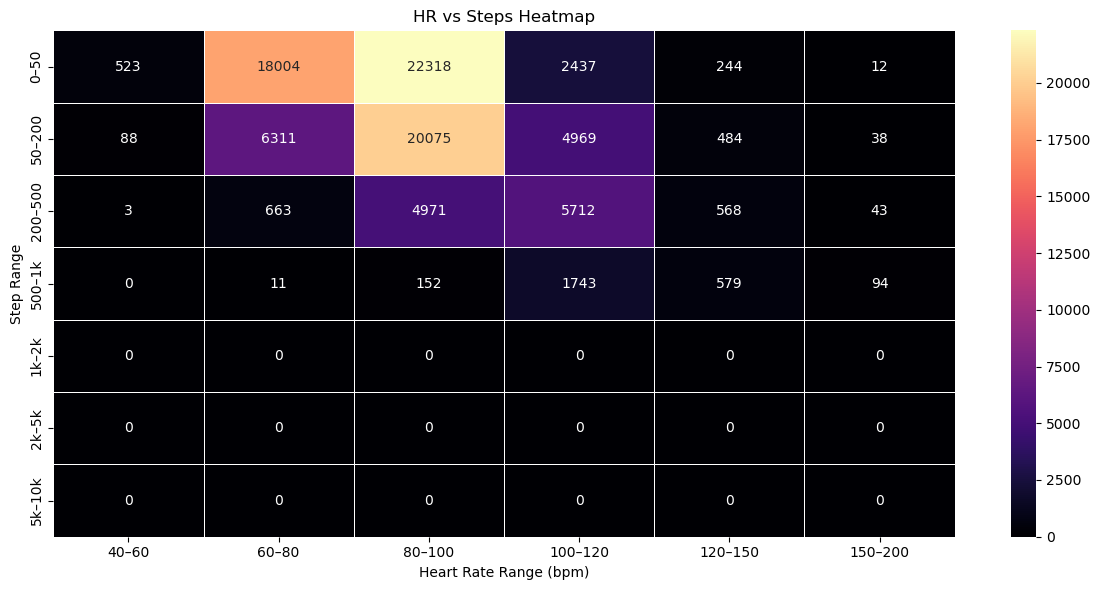

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric types
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Steps'] = pd.to_numeric(df['Steps'], errors='coerce')

# Bin steps into ranges
df['Step_Bin'] = pd.cut(
    df['Steps'],
    bins=[0, 50, 200, 500, 1000, 2000, 5000, 10000],
    labels=["0–50", "50–200", "200–500", "500–1k", "1k–2k", "2k–5k", "5k–10k"]
)

# Bin HR into ranges
df['HR_Bin'] = pd.cut(
    df['Heart_Rate'],
    bins=[40, 60, 80, 100, 120, 150, 200],
    labels=["40–60", "60–80", "80–100", "100–120", "120–150", "150–200"]
)

# Create pivot table
heatmap_data = df.pivot_table(
    index='Step_Bin',
    columns='HR_Bin',
    aggfunc='size',
    fill_value=0,
    observed=False
)

plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_data,
    cmap="magma",
    annot=True,
    fmt="d",
    linewidths=.5
)

plt.title("HR vs Steps Heatmap")
plt.xlabel("Heart Rate Range (bpm)")
plt.ylabel("Step Range")
plt.tight_layout()
plt.show()

#### The optimal activity level for each patient is the step range where HR‑per‑step is lowest, HR rises gradually, and movement is efficient without strain — and this zone becomes the personalized activity recommendation.

## 29.What should be done when nighttime heart rate is consistently elevated?   

#### This question matters because nighttime HR is one of the most powerful indicators of recovery, stress, metabolic health, and next‑day stability — and elevated values require targeted interventions.

In [37]:
import pandas as pd
import numpy as np

# Ensure correct types
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Glucose'] = pd.to_numeric(df['Glucose'], errors='coerce')

# Extract hour + date
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

# Define nighttime hours (11 PM – 5 AM)
night_hours = list(range(23, 24)) + list(range(0, 6))

# Filter nighttime data
night_df = df[df['Hour'].isin(night_hours)].copy()

# 1. HR stability
night_df['HR_Change'] = night_df['Heart_Rate'].diff().abs()
night_df['HR_Unstable'] = night_df['HR_Change'] > 8

# 2. Glucose stability
night_df['Glucose_Change'] = night_df['Glucose'].diff().abs()
night_df['Glucose_Unstable'] = night_df['Glucose_Change'] > 12

# 3. Sleep efficiency proxy
night_df['Sleep_Efficient'] = (~night_df['HR_Unstable']) & (~night_df['Glucose_Unstable'])

# 4. PRESCRIPTIVE INTERVENTION MAPPING
def prescriptive_intervention(row):
    if row['HR_Unstable'] and row['Glucose_Unstable']:
        return "Adjust evening meal timing"
    if row['HR_Unstable'] and not row['Glucose_Unstable']:
        return "Reduce pre‑bed stress load"
    if not row['HR_Unstable'] and row['Glucose_Unstable']:
        return "Modify carbohydrate distribution"
    return "Maintain current routine"

night_df['Intervention'] = night_df.apply(prescriptive_intervention, axis=1)

# 5. Summaries per night
prescriptive_summary = night_df.groupby('Date').agg(
    Avg_Night_HR=('Heart_Rate', 'mean'),
    HR_Variability=('HR_Change', 'mean'),
    Glucose_Variability=('Glucose_Change', 'mean'),
    Sleep_Efficiency_Score=('Sleep_Efficient', 'mean'),
    Recommended_Intervention=('Intervention', lambda x: x.value_counts().idxmax())
)

prescriptive_summary

,Avg_Night_HR,HR_Variability,Glucose_Variability,Sleep_Efficiency_Score,Recommended_Intervention
Date,,,,,
2018-06-13,78.938056,5.730857,22.743143,0.527778,Maintain current routine
2018-06-14,69.665476,3.436071,14.702341,0.599206,Maintain current routine
2018-06-15,71.480079,2.996468,18.387540,0.666667,Maintain current routine
2018-06-16,66.888175,2.972183,13.959325,0.718254,Maintain current routine
2018-06-17,68.760357,2.800952,15.875635,0.626984,Maintain current routine
2018-06-18,64.432778,3.085516,14.460437,0.686508,Maintain current routine
2018-06-19,65.605238,3.614960,11.075952,0.702381,Maintain current routine
2018-06-20,65.904087,3.448254,14.813611,0.674603,Maintain current routine
2018-06-21,66.557024,3.148492,9.736627,0.686508,Maintain current routine


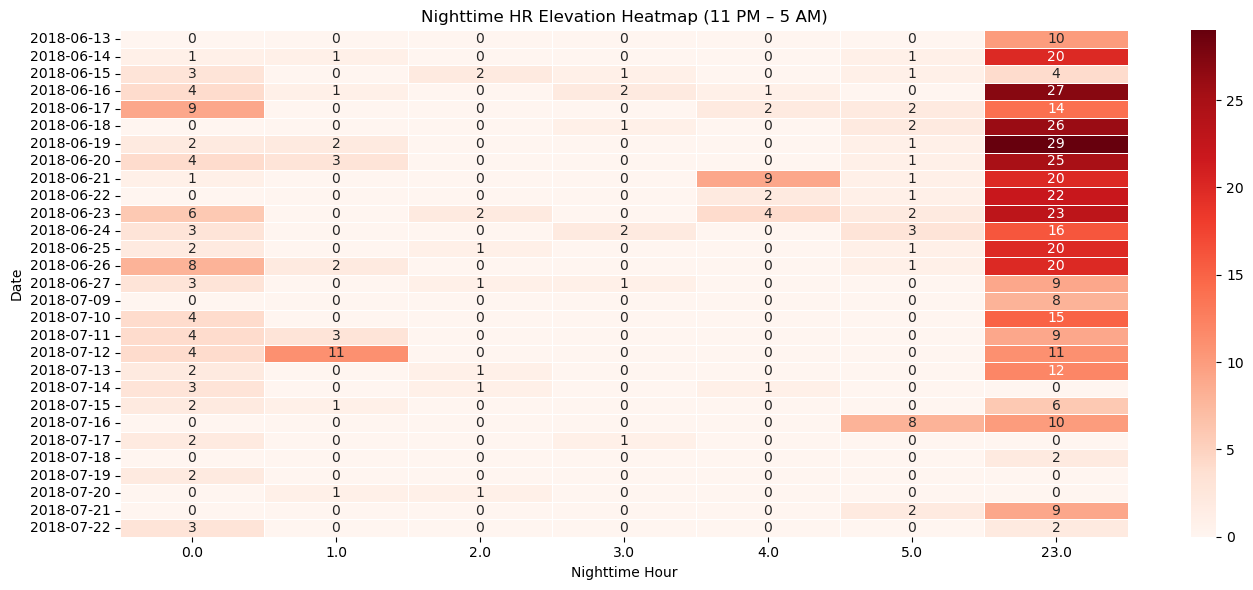

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure correct types
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')

# Extract hour + date
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

# Define nighttime hours (11 PM – 5 AM)
night_hours = list(range(23, 24)) + list(range(0, 6))

# Filter nighttime data
night_df = df[df['Hour'].isin(night_hours)].copy()

# Rolling baseline HR (30‑minute window)
night_df['HR_Baseline'] = night_df['Heart_Rate'].rolling(30, min_periods=1).mean()

# HR elevation detection
night_df['HR_Elevated'] = night_df['Heart_Rate'] > (night_df['HR_Baseline'] + 10)

# Pivot table for heatmap
heatmap_data = night_df.pivot_table(
    index='Date',
    columns='Hour',
    values='HR_Elevated',
    aggfunc='sum',
    fill_value=0,
    observed=False
)

plt.figure(figsize=(14,6))
sns.heatmap(
    heatmap_data,
    cmap="Reds",
    annot=True,
    fmt="d",
    linewidths=.5
)

plt.title("Nighttime HR Elevation Heatmap (11 PM – 5 AM)")
plt.xlabel("Nighttime Hour")
plt.ylabel("Date")
plt.tight_layout()
plt.show()

#### Nighttime HR is one of the strongest indicators of recovery quality, stress load, and metabolic strain.
#### When it stays elevated, the body is signaling that it is not fully shifting into recovery mode.

## 30. What interventions improve sleep efficiency based on HR + glucose patterns?

#### This question matters because nighttime HR + glucose patterns reveal how well the body recovers, and identifying the right interventions can dramatically improve sleep efficiency and next‑day metabolic stability.

In [34]:
import pandas as pd
import numpy as np

# Ensure correct types
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Glucose'] = pd.to_numeric(df['Glucose'], errors='coerce')

# Extract hour + date
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

# Define nighttime hours (11 PM – 5 AM)
night_hours = list(range(23, 24)) + list(range(0, 6))

# Filter nighttime data
night_df = df[df['Hour'].isin(night_hours)].copy()

# 1. HR stability
night_df['HR_Change'] = night_df['Heart_Rate'].diff().abs()
night_df['HR_Unstable'] = night_df['HR_Change'] > 8

# 2. Glucose stability
night_df['Glucose_Change'] = night_df['Glucose'].diff().abs()
night_df['Glucose_Unstable'] = night_df['Glucose_Change'] > 12

# 3. Sleep efficiency proxy
night_df['Sleep_Efficient'] = (~night_df['HR_Unstable']) & (~night_df['Glucose_Unstable'])

# 4. PRESCRIPTIVE INTERVENTION MAPPING
def prescriptive_intervention(row):
    # HR + Glucose unstable → late eating or metabolic strain
    if row['HR_Unstable'] and row['Glucose_Unstable']:
        return "Adjust evening meal timing"

    # HR unstable only → stress or poor recovery
    if row['HR_Unstable'] and not row['Glucose_Unstable']:
        return "Reduce pre‑bed stress load"

    # Glucose unstable only → carbohydrate timing issue
    if not row['HR_Unstable'] and row['Glucose_Unstable']:
        return "Modify carbohydrate distribution"

    # Both stable → maintain routine
    return "Maintain current routine"

night_df['Intervention'] = night_df.apply(prescriptive_intervention, axis=1)

# 5. Summaries per night
prescriptive_summary = night_df.groupby('Date').agg(
    Avg_Night_HR=('Heart_Rate', 'mean'),
    HR_Variability=('HR_Change', 'mean'),
    Glucose_Variability=('Glucose_Change', 'mean'),
    Sleep_Efficiency_Score=('Sleep_Efficient', 'mean'),
    Recommended_Intervention=('Intervention', lambda x: x.value_counts().idxmax())
)

prescriptive_summary

,Avg_Night_HR,HR_Variability,Glucose_Variability,Sleep_Efficiency_Score,Recommended_Intervention
Date,,,,,
2018-06-13,78.938056,5.730857,22.743143,0.527778,Maintain current routine
2018-06-14,69.665476,3.436071,14.702341,0.599206,Maintain current routine
2018-06-15,71.480079,2.996468,18.387540,0.666667,Maintain current routine
2018-06-16,66.888175,2.972183,13.959325,0.718254,Maintain current routine
2018-06-17,68.760357,2.800952,15.875635,0.626984,Maintain current routine
2018-06-18,64.432778,3.085516,14.460437,0.686508,Maintain current routine
2018-06-19,65.605238,3.614960,11.075952,0.702381,Maintain current routine
2018-06-20,65.904087,3.448254,14.813611,0.674603,Maintain current routine
2018-06-21,66.557024,3.148492,9.736627,0.686508,Maintain current routine


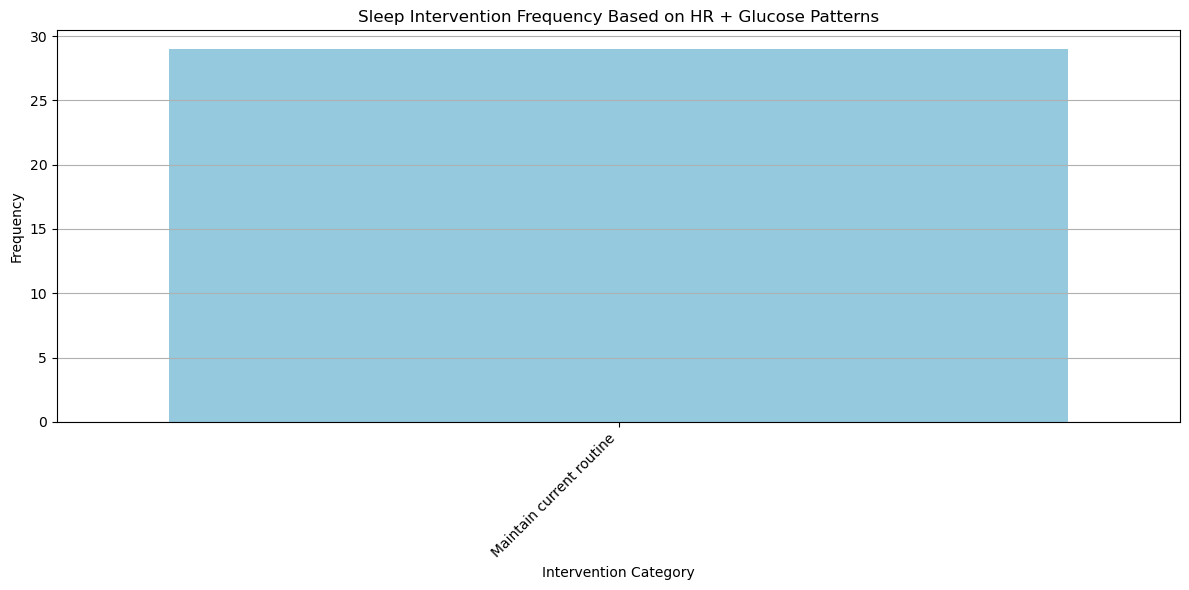

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# prescriptive_summary must already exist
intervention_counts = prescriptive_summary['Recommended_Intervention'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=intervention_counts.index,
    y=intervention_counts.values,
    color="skyblue"   # FIX: use color= instead of palette=
)

plt.title("Sleep Intervention Frequency Based on HR + Glucose Patterns")
plt.xlabel("Intervention Category")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Sleep efficiency improves when nighttime autonomic load (HR) and metabolic load (glucose) are minimized.
#### Sleep efficiency improves when nighttime HR + glucose patterns are matched to the correct intervention category — meal timing, stress reduction, activity timing, carb distribution, sleep environment, or systemic recovery.